# Econometrics
## BSc AIDAMS

Prof. Roberto Renò - ESSEC Business School 

Based on:
**[gabors-data-analysis.com ](https://gabors-data-analysis.com/)**

 License: Free to share, modify and use for educational purposes. 
 Not to be used for commercial purposes.

## Hypothesis Testing

In [1]:
import os
import sys
import warnings

import numpy as np
import pandas
import seaborn as sns
from mizani.formatters import percent_format
from plotnine import *

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore")

# Current script folder
current_path = os.getcwd()
dirname = current_path.split("da_case_studies")[0]

# location folders (double check you have this on your pc)
data_in = dirname + "/Data/"
data_out = dirname + "/Data/"
output = dirname + "/output/"
func = dirname + "/Settings/"
sys.path.append(func)

# Import the prewritten helper functions
from py_helper_functions import *

In [2]:
pd = pandas.read_csv(data_in + "online_offline_ALL_clean.csv", encoding="latin1")

In [3]:
# FILTER DATA
pd = pd.loc[
    lambda x: (x["COUNTRY"] == "USA")
    & (x["PRICETYPE"] == "Regular Price")
    & (x["sale_online"].isnull())
    & (~x["price"].isnull())
    & (~x["price_online"].isnull())
]

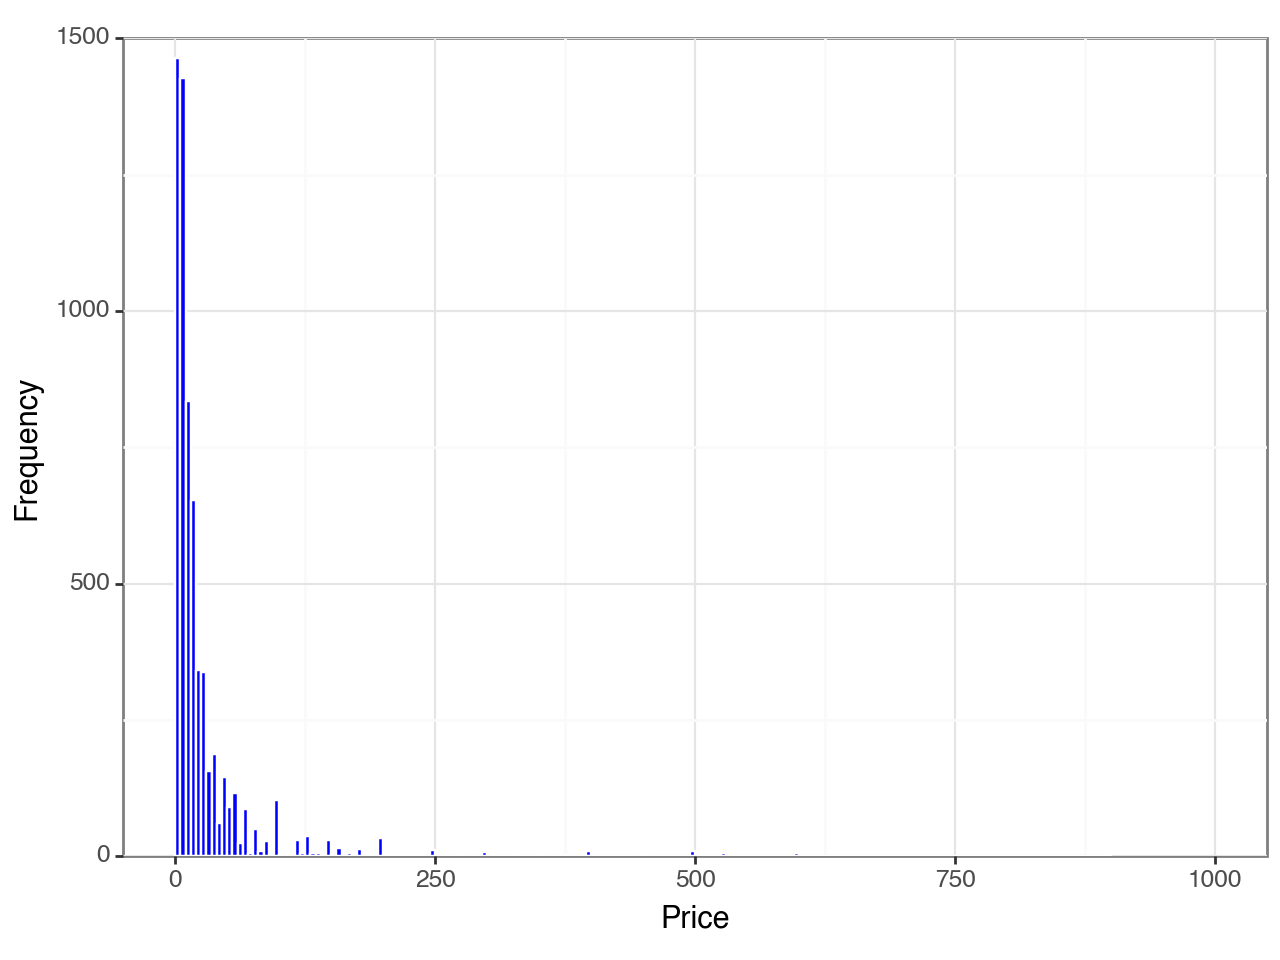

<Figure Size: (640 x 480)>

In [8]:
ggplot(pd, aes("price")) + geom_histogram(
    binwidth=5, color="white", fill="blue", boundary=0, closed="left"
) + labs(
    x="Price", y="Frequency"
) + coord_cartesian(
    xlim=[0, 1000], ylim=[0, 1500]
) + scale_y_continuous(
    expand=[0, 0]
) + theme_bw()

In [7]:
# Drop obvious errors
pd = pd.loc[lambda x: x["price"] < 1000]

In [9]:
# Compare variables
pd["diff"] = pd["price_online"] - pd["price"]
descr = pd["diff"].describe()

In [10]:
descr

count    6439.000000
mean        0.054460
std         9.994452
min      -380.130000
25%        -0.040000
50%         0.000000
75%         0.000000
max       415.270000
Name: diff, dtype: float64

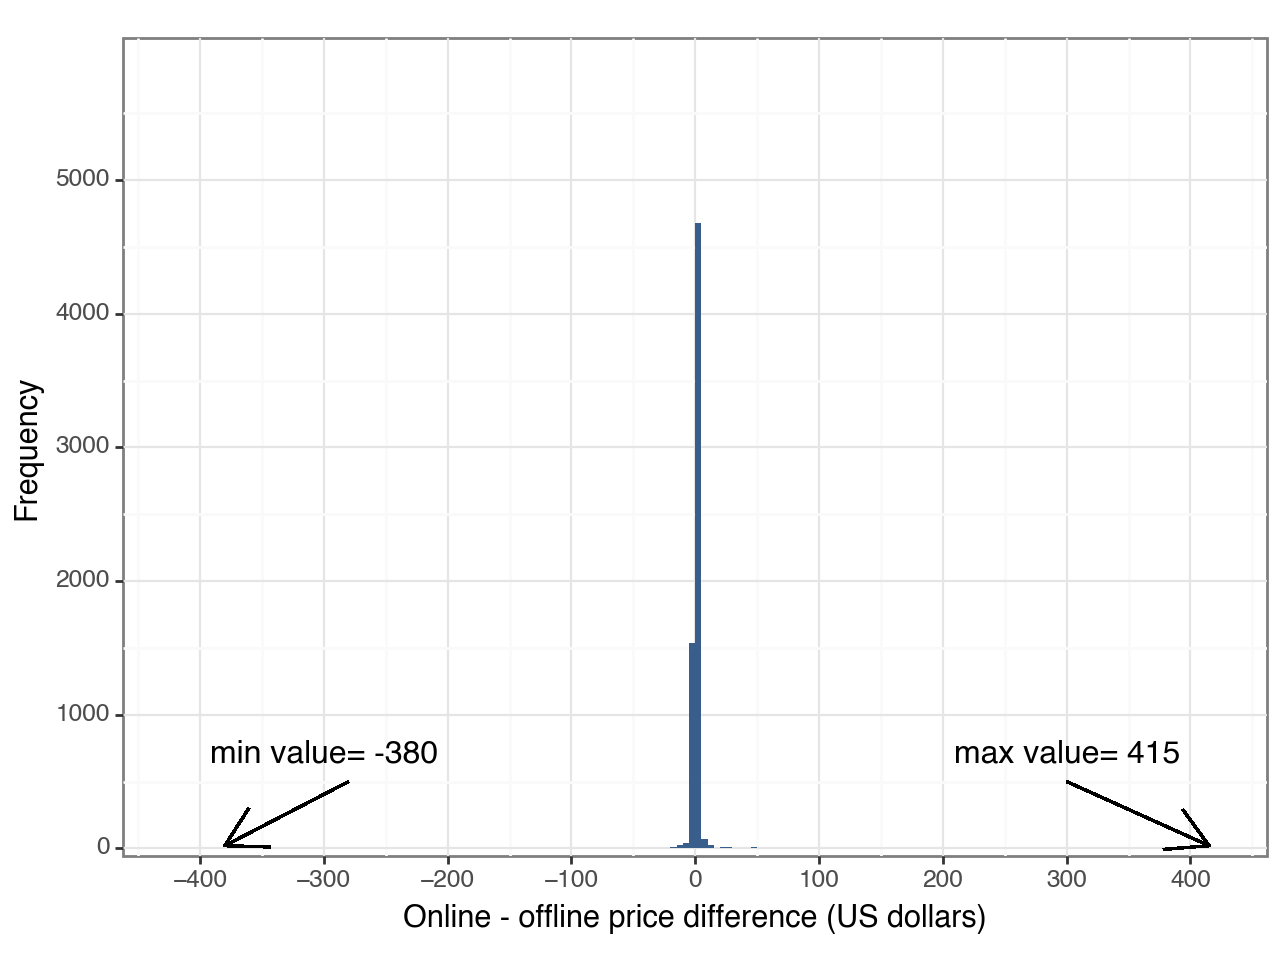

<Figure Size: (640 x 480)>

In [11]:
ggplot(pd, aes("diff")) + geom_histogram(
    binwidth=5,
    boundary=0,
    fill=color[0],
    size=0.25,
    alpha=0.8,
    show_legend=False,
    na_rm=True,
    closed="left"
) + labs(
    x="Online - offline price difference (US dollars)", y="Frequency"
) + theme_bw() + scale_x_continuous(
    limits=(-420, 420), breaks=seq(-400, 420, by=100)
) + scale_y_continuous(
    limits=(0, 6000), breaks=seq(0, 6000, by=1000), expand=(0.01, 0.01)
) + geom_segment(
    aes(x=300, y=500, xend=415, yend=20), arrow=arrow()
) + annotate(
    "text", x=300, y=700, label="max value= 415", size=11.5
) + geom_segment(
    aes(x=-280, y=500, xend=-380, yend=20), arrow=arrow()
) + annotate(
    "text", x=-300, y=700, label="min value= -380", size=11.5
)

In [12]:
# 4.99999 not 5 -- needed because of data imported from stata may be stored wierdly.
pd1 = pd.query("abs(diff)<4.999999")
pd1["diff"].describe()

count    6200.000000
mean       -0.127437
std         0.788358
min        -4.900000
25%         0.000000
50%         0.000000
75%         0.000000
max         4.990000
Name: diff, dtype: float64

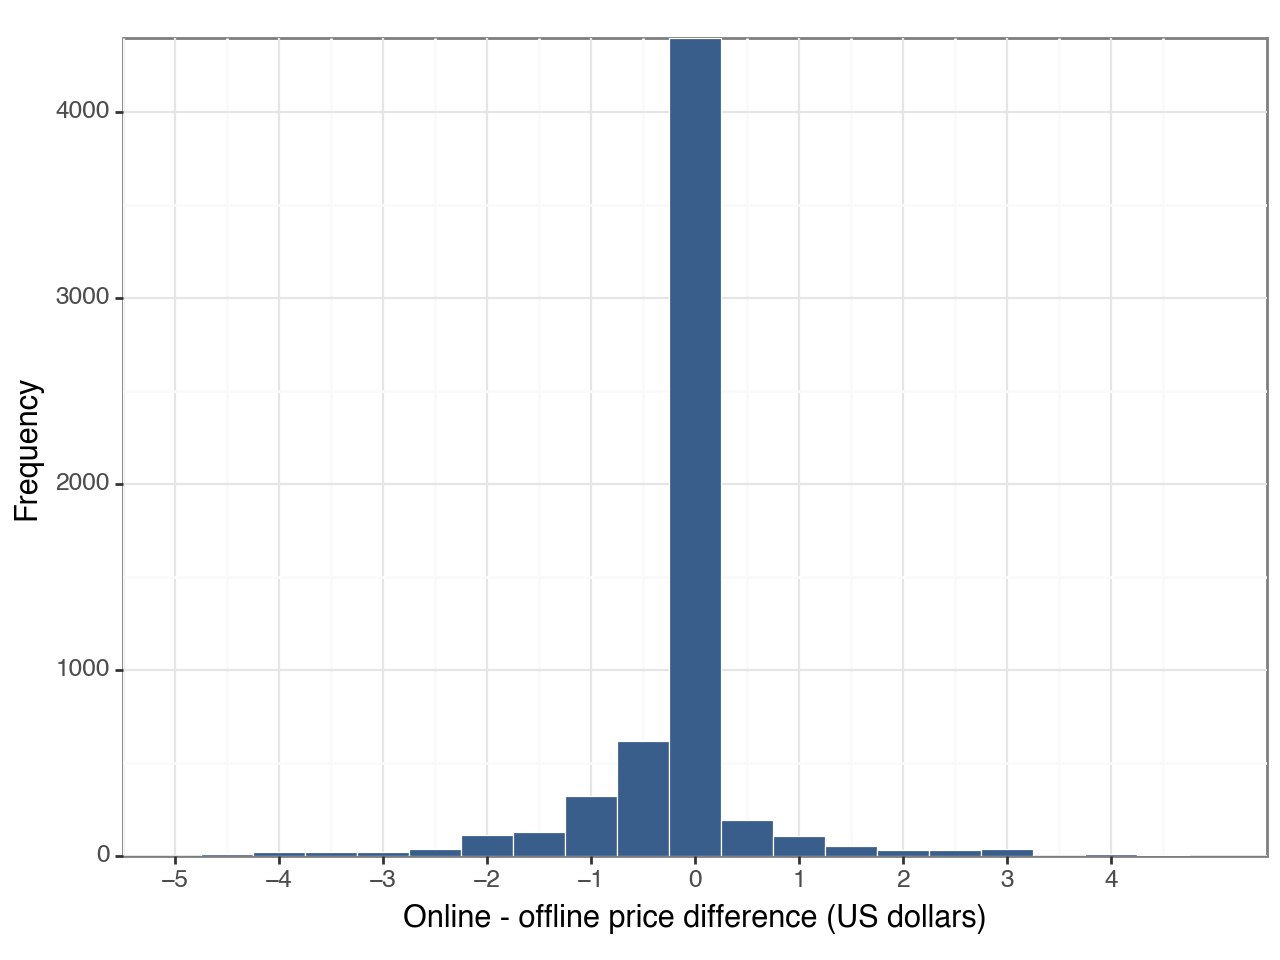

<Figure Size: (640 x 480)>

In [13]:
ggplot(pd, aes("diff")) + geom_histogram(
    binwidth=0.5,
    center=0.5,
    color="white",
    fill=color[0],
    size=0.25,
    alpha=0.8,
    show_legend=False,
    na_rm=True
) + labs(
    x="Online - offline price difference (US dollars)", y="Frequency"
) + theme_bw() + expand_limits(
    x=0.01, y=0.01
) + scale_x_continuous(
    limits=(-5, 5), breaks=seq(-5, 5, by=1)
) + scale_y_continuous(
    expand=(0.00, 0.00)
)

In [14]:
# HYPOTHESIS
from scipy import stats

stats.ttest_1samp(pd["diff"], 0)

TtestResult(statistic=0.4372481266029261, pvalue=0.6619460766193054, df=6438)

In [ ]:
def t_test_1samp(series, mu=0):
    """
    This is a function to calculate t_test for 1 sample.
    Return: tuple of 2 elements, first is sample mean, second is t test object from scipy
    """
    return (np.mean(series), stats.ttest_1samp(series, mu))

In [ ]:
# MULTIPLE HYPOTHESES
spd = [pd.loc[pd["retailer"] == x,] for x in set(pd["retailer"])]
out = [(set(x["retailer"]), t_test_1samp(x["diff"], 0)) for x in spd]

In [ ]:
out

In [ ]:
table_out = pandas.DataFrame.from_records(
    [
        {"retailer": list(x[0])[0], "estimate": x[1][0], "p.value": x[1][1].pvalue*100}
        for x in out
    ]
)

In [ ]:
pandas.set_option('display.float_format', '{:.6f}'.format)
table_out